# Data Science Revisiting some topics
Prepared for Turing-style technical interviews.
Generated on 2026-02-14 22:43:02


## Dataset 1 — Pricing & Elasticity
Objective: Estimate price elasticity and evaluate revenue impact.


In [52]:
import numpy
import numpy as np
import pandas as pd
np.random.seed(42)
n = 500

price = np.random.uniform(10, 100, n)
seasonality = np.random.choice([0, 1], size=n)
marketing = np.random.uniform(0, 50, n)

noise = np.random.normal(0, 5, n)
quantity = 200 - 1.5 * price + 20 * seasonality + 0.8 * marketing + noise
quantity = np.maximum(quantity, 1)
revenue = price * quantity

df_pricing = pd.DataFrame({
    'price': price,
    'seasonality': seasonality,
    'marketing': marketing,
    'quantity': quantity,
    'revenue': revenue
})

df_pricing.head()

,price,seasonality,marketing,quantity,revenue
0,43.708611,1,5.844902,158.664327,6934.997305
1,95.564288,0,46.991606,101.447440,9694.752297
2,75.879455,0,31.385403,107.907178,8187.937867
3,63.879264,0,16.745281,126.582031,8085.966947
4,24.041678,0,6.963604,169.307577,4070.438181


### Exercises
1. Compute correlation between price and quantity.
2. Plot scatter and detect outliers (IQR method).
3. Estimate elasticity using linear regression.
4. Compute VIF and test multicollinearity.


In [53]:
#np.corrcoef(df_pricing[['price','quantity']].T)
df_pricing[['price','quantity']].corr()


,price,quantity
price,1.000000,-0.927168
quantity,-0.927168,1.000000


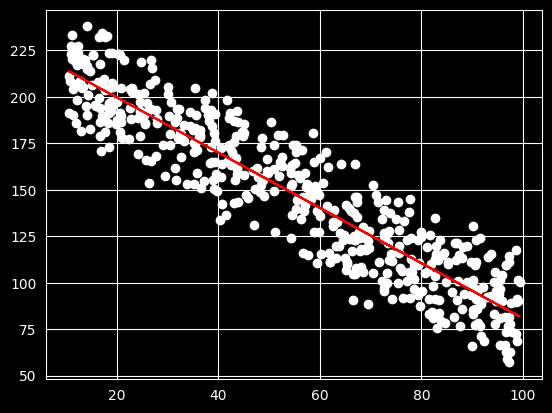

In [54]:
import matplotlib
from matplotlib import pyplot as plt

plt.scatter(df_pricing['price'],df_pricing['quantity'],c='white')
b1, b0 = np.polyfit(df_pricing['price'], df_pricing['quantity'], 1)
plt.plot(df_pricing['price'],b0+b1*df_pricing['price'],c='red')


In [55]:
-from statsmodels.stats.outliers_influence import variance_inflation_factor
df_pricing.columns
#variance_inflation_factor(df_pricing['price'], df_pricing['quantity'])

import statsmodels.api as sm
import statsmodels.formula.api as fsm
#sm.OLS(df_pricing['price'], df_pricing['quantity']).fit()

## definir uma regressao para cada Xi contra X_j para i != j
exogenous = ['price', 'seasonality', 'marketing', 'quantity', 'revenue']
FORMULA = "price ~ marketing"
model_x1 = fsm.ols(
    FORMULA,
    data = df_pricing
)
x1_results = model_x1.fit()
x1_results.params
# residuals: y_i - y_predicted
#vif = (1/(1-R²))
# R² = 1 - (SQReg/SQTotal)
#VIF(X1)
Vifx1 = 1/(1-x1_results.rsquared)
Vifx1

x1_results.summary()
## interpret VIF for this case




SyntaxError: invalid syntax (3730400731.py, line 1)

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf




## Dataset 2 — Customer Churn Classification
Objective: Predict churn using logistic regression and boosting.


In [ ]:
np.random.seed(42)
n = 1000

tenure = np.random.randint(1, 72, n)
monthly_charges = np.random.uniform(20, 120, n)
contract = np.random.choice([0, 1], n)

logit = -0.03 * tenure + 0.02 * monthly_charges - 1.2 * contract
prob = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, prob)

df_churn = pd.DataFrame({
    'tenure': tenure,
    'monthly_charges': monthly_charges,
    'contract': contract,
    'churn': churn
})

df_churn.head()

### Exercises
1. Calculate churn rate by contract type.
2. Train Logistic Regression and Gradient Boosting.
3. Evaluate ROC-AUC and Precision/Recall.
4. Interpret coefficients and odds ratios.


## Dataset 3 — Multicollinearity Experiment
Objective: Observe coefficient instability and apply Ridge regression.


In [ ]:
np.random.seed(42)
n = 300

x1 = np.random.normal(0, 1, n)
x2 = 2 * x1 + np.random.normal(0, 0.01, n)
x3 = np.random.normal(0, 1, n)

y = 3 * x1 + 2 * x3 + np.random.normal(0, 1, n)

df_multi = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'x3': x3,
    'y': y
})

df_multi.head()

### Exercises
1. Fit linear regression with x1, x2, x3.
2. Compute VIF.
3. Compare with Ridge regression.
4. Explain why variance explodes mathematically.


## Algorithm Practice
1. Implement RMSE from scratch.
2. Implement train/test split without sklearn.
3. Solve maximum stock profit problem (O(n)).
4. Implement linear regression using normal equation.
5. Implement gradient descent.


#1 implementing RMSE from scratch
$$RMSE = \sqrt{\frac{\sum_{i=1}^n(y_i - \hat{y_i})^2}{n-p}}$$

In [ ]:
def rmse_1(y: np.array, y_hat: np.array, p: int) -> np.float64:
    return np.sqrt(np.sum((y-y_hat)**2)/len(y))

y  = np.array([1,2,4.23,2,2,1,3])
y_hat =  np.array([5,24.223,1,21,34,4,5])

rmse_1(y,y_hat,1)

## implementacao mais simples possivel


## implementando o GD

gradiente descendente é basicamente uma heuristica de otimizacao que consiste em minimizar uma funcao real definida em $R^n$ usando usando um metodo iterativo a partir de um ponto escolhido sob algum criterio inicial. ${\nabla} f(x) = 0$ para encontrar um maximo ou mínimo local.

Seja f uma função $$f: R^n \rightarrow R$$
e defina $$\nabla_f \ \  = \ \  (\frac{\partial f}{\partial x_1} \ldots \frac{\partial f}{\partial x_n}) $$

1. Defina um ponto, $P_0$
2. no passo um faça: $ P1 = P_0 - \alpha \cdot \nabla_f(P_0) $
3. no passo k faça: $ P_{k+1} = P_k - \alpha \cdot \nabla_f((P_k))  $
4. pare quando $||\nabla_f|| < e $ para e > 0 pequeno.

In [ ]:
from numpy import gradient
from typing import Callable
from numpy.linalg import norm
def gd_1(
        grad: Callable[[np.ndarray], np.ndarray],
        x0: np.ndarray,
        lr: float,
        tol: float,
        max_iter: int
) -> np.ndarray:
    xk = x0
    ek = 10
    k = 0
    while(ek > tol):
        gradk = grad(xk)
        ek  = np.linalg.norm(gradk)
        print(f"gradiente no ponto {xk} = {gradk} ")
        xk = xk-lr*gradk
        k += 1
        if k >= max_iter:
            break
    return(xk)


In [ ]:
import numpy as np
def grad_test(x: np.ndarray) -> np.ndarray:
    return 2 * x
# Ponto inicial
x0 = np.array([10.0, -5.0])

# Parâmetros
lr = 0.1
tol = 1e-8
max_iter = 1000

# Rodando o GD
resultado = gd_1(
    grad=grad_test,
    x0=x0,
    lr=lr,
    tol=tol,
    max_iter=max_iter
)

print("\nResultado final:", resultado)
print("Norma final:", np.linalg.norm(resultado))

$$f(x,y) =  xy^2+\frac{3x}{y} $$
$$\nabla_f = (y^2+\frac{3}{y}, 2xy-\frac{3x}{y^2})$$

In [ ]:
def grad_f(v: np.ndarray, lam: float) -> np.ndarray:
    x = v[0]
    y = v[1]
    return np.array([y**2+3/y, 2*x*y - 3*x/y**2])+ lam * 2* v


# Ponto inicial

# Parâmetros
lr = 1e-4
tol = 1e-5
max_iter = 20000

# Rodando o GD
resultado = gd_2(
    grad=lambda v: grad_f(v, lam=0.8),
    x0= np.array([10.0, 1]),
    lr=lr,
    tol=tol,
    max_iter=max_iter
)

print("\nResultado final:", resultado)
print("Norma final:", np.linalg.norm(resultado))

In [ ]:
from numpy import gradient
from typing import Callable
from numpy.linalg import norm
def gd_2(
        grad: Callable[[np.ndarray], np.ndarray],
        x0: np.ndarray,
        lr: float,
        tol: float,
        max_iter: int,
        clip = 10
) -> np.ndarray:
    xk = x0
    ek = 10
    k = 0
    while(ek > tol):
        gradk = grad(xk)
        ek  = np.linalg.norm(gradk)
        print(f"gradiente no ponto {xk} = {gradk} ")
        xk = xk-lr*gradk
        k += 1
        if ek > clip:
            gradk = gradk*(clip/ek)
        if k >= max_iter:
            break

    return(xk)

### 4. Implement linear regression using normal equation.
the classic multivariate linear regression is defined by :  $$ Y = \beta_0+\beta_1X_1 + \ldots + \beta_kXk +\varepsilon $$ where $\varepsilon$ follows some distribution with
 $$\varepsilon \overset{\text{iid}}{\sim} (o, \sigma^2\textbf{I})$$
 not necessarily Normal distributed
 in such way that $$ Y \overset{\text{iid}}{\sim} (\beta_0+ \sum_{i=1}^k \beta_iX_i,  \ \sigma^2 ) $$
 In the vetorial form: $$ Y = \textbf{X} \boldsymbol\beta + \boldsymbol{\varepsilon} \\  $$ $$\boldsymbol{\varepsilon} \overset{\text{iid}}{\sim} (\textbf{0}, {\sigma^2} \textbf{I})$$

Let the model error is defined by $$S(\beta) = (y - \textbf{X}\beta)^\intercal  (y - \textbf{X}\beta) = ||r(\beta)||^2$$

lets expand this equation into $$(y^\intercal-\boldsymbol{\beta^\intercal} \boldsymbol{X}^\intercal)(y-\boldsymbol{X} \beta)$$\

$$$$\
$$
\begin{aligned}
y^\intercal y -\boldsymbol{\beta^\intercal} \boldsymbol{X}^\intercal y +y^\intercal \boldsymbol{X} \beta + \boldsymbol{\beta^\intercal} \boldsymbol{X}^\intercal \boldsymbol{X} \\ &=
 y^\intercal y - 2\boldsymbol{\beta^\intercal} \boldsymbol{X}^\intercal y + \boldsymbol{\beta^\intercal} \boldsymbol{X}^\intercal \boldsymbol{X} \beta
\end{aligned}
$$

Let's differentiate this
$$\frac{\partial}{\partial \beta}S(\beta)$$
$$\frac{\partial}{\partial \beta}(y^\intercal y) = 0$$
$$\frac{\partial}{\partial \beta}(- 2\boldsymbol{\beta^\intercal} \boldsymbol{X}^\intercal y ) = - 2\boldsymbol{X}^\intercal y $$
$$\frac{\partial}{\partial\beta} (\boldsymbol{\beta^\intercal} \boldsymbol{X}^\intercal \boldsymbol{X} \beta) =  2\boldsymbol{X}^\intercal \boldsymbol{X}\beta $$

Therefore:
$$
\begin{aligned}
\frac{\partial}{\partial \beta}S(\beta)&= - 2\boldsymbol{X}^\intercal y+ 2\boldsymbol{X}^\intercal \boldsymbol{X}\beta
\end{aligned}
$$

$$ - 2\boldsymbol{X}^\intercal y+ 2\boldsymbol{X}^\intercal \boldsymbol{X}\beta = 0$$